<a href="https://colab.research.google.com/github/Janvi007-max/Machine-Learning-Projects/blob/main/DAY1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
np.random.seed(0)

x = np.sort(5 * np.random.rand(25,1),axis=0)
y = np.sin(x).ravel()
y += np.random.normal(0,0.25,size=y.shape)

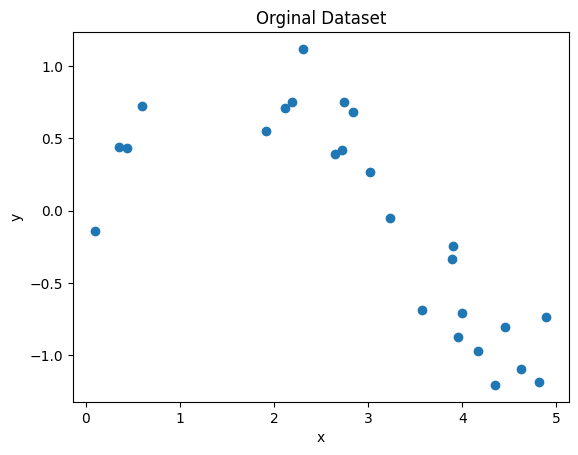

In [ ]:
plt.scatter(x,y)

plt.title("Orginal Dataset")

plt.xlabel("x")

plt.ylabel("y")

plt.show()

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
def fit_and_plot(degree, subplot_position, title):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(x_train)
    X_test_poly = poly.transform(x_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    x_plot = np.linspace(0, 5, 200).reshape(-1, 1)
    x_plot_poly = poly.transform(x_plot)

    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))

    plt.subplot(1, 3, subplot_position)
    plt.scatter(x_train, y_train, color="blue", label="Train")
    plt.scatter(x_test, y_test, color="red", label="Test")
    plt.plot(x_plot, model.predict(x_plot_poly), color="black")
    plt.title(f"{title}\nTrain MSE={train_mse:.2f}\nTest MSE={test_mse:.2f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

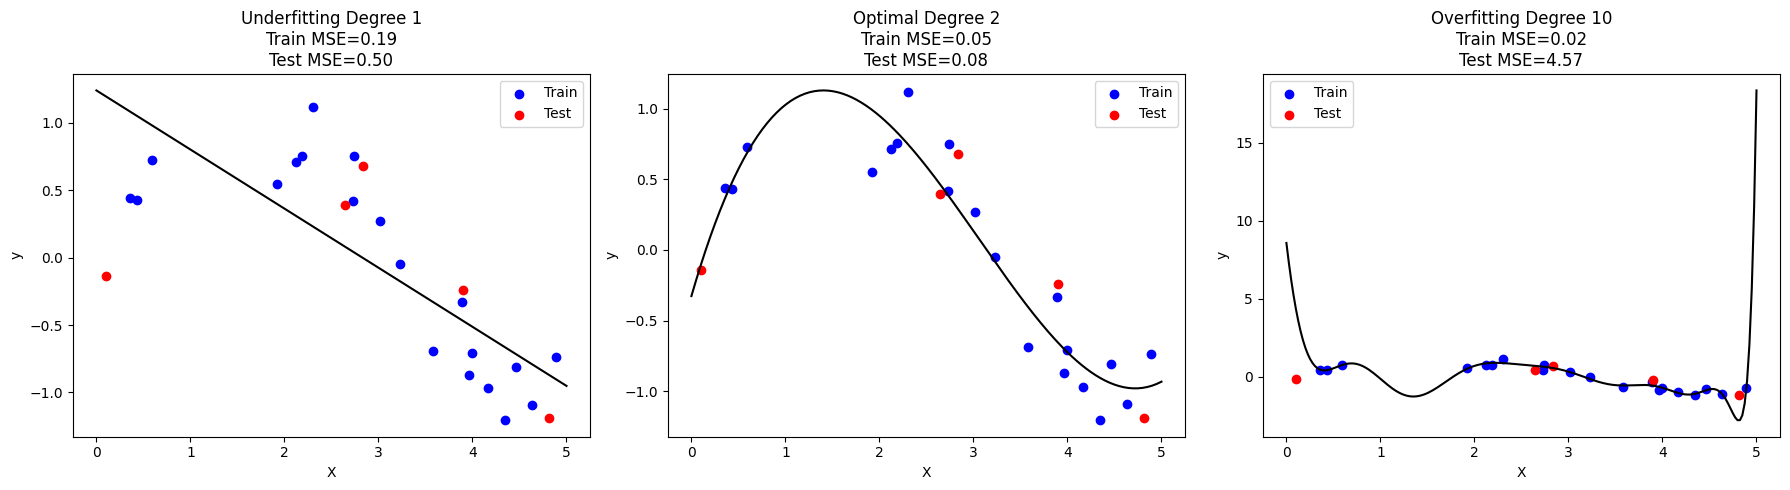

In [ ]:
plt.figure(figsize=(18, 5))

fit_and_plot(degree=1, subplot_position=1, title="Underfitting Degree 1")
fit_and_plot(degree=3, subplot_position=2, title="Optimal Degree 2")
fit_and_plot(degree=15, subplot_position=3, title="Overfitting Degree 10")

plt.tight_layout()
plt.show()